In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler

In [2]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_val.csv"
TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

In [3]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
dataframe_train

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.081990,0.128940,1.944260,1.389343,86.1054,22.1204,220.457,75.0000,113.388641,0.018525,...,0.236338,0.007450,0.000167,0.091304,0.003896,0.119160,29.465597,73.191716,Fluid Leaks,11.0
1,0.027328,0.039679,1.317660,1.401284,70.4713,24.8744,237.341,29.0000,180.123097,0.048320,...,0.265105,0.005588,0.000012,0.067804,0.005476,0.000000,8.241915,19.227102,Inlet Valve Malfunction,12.0
2,0.635957,0.716170,2.151870,0.746920,88.1113,29.3807,227.128,125.6790,105.549127,0.005943,...,0.212093,0.006412,0.006357,0.218608,0.002300,0.132600,33.220177,71.301521,Sharp - Rotor Imbalance,1.0
3,0.027019,0.039735,1.095630,1.073357,71.7012,25.3806,237.699,32.0000,216.951891,0.033542,...,0.323904,0.005583,0.000017,0.095680,0.003692,0.000000,9.094527,7.628241,No Anomaly,0.0
4,0.204735,0.278139,2.481440,1.074847,90.9473,26.9181,231.407,122.0000,93.255126,0.008810,...,0.186333,0.006993,0.000524,0.054564,0.004032,0.252480,32.093964,75.654561,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7375,0.027530,0.041255,1.354630,0.745430,70.0092,24.9753,239.841,32.0131,177.052775,0.023285,...,0.253508,0.003198,0.000026,0.066080,0.005964,0.469712,14.079647,50.450786,No Anomaly,0.0
7376,0.215588,0.267894,2.461090,1.074847,89.4948,28.4908,229.419,126.0000,93.218452,0.008531,...,0.186476,0.007710,0.000353,0.028312,0.005812,0.053080,30.381219,38.480829,No Anomaly,0.0
7377,0.027744,0.040973,0.928190,1.073357,67.6991,24.4987,227.230,32.0312,244.809791,0.033510,...,0.377626,0.007399,0.000015,0.083984,0.002860,0.306560,5.544434,25.461602,No Anomaly,0.0
7378,0.228345,0.274455,3.039520,1.074847,87.6964,29.9647,250.379,128.0000,82.374520,0.008397,...,0.135569,0.006140,0.001061,0.114580,0.006340,0.353440,0.633158,67.553684,No Anomaly,0.0


In [4]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
dataframe_test

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,description,anomaly
0,0.210323,0.262893,2.658640,1.074847,88.6217,29.3147,230.091,126.6770,86.544624,0.008485,...,0.170436,0.007359,0.000450,0.115096,0.005824,0.285160,8.584219,126.989244,No Anomaly,0.0
1,0.028297,0.042536,0.814120,0.745430,68.0318,24.2354,232.174,32.0000,285.184002,0.023295,...,0.423439,0.005650,0.000042,0.111232,0.004348,0.038412,16.180027,34.680405,No Anomaly,0.0
2,0.028185,0.041387,0.810610,1.073357,68.8750,24.7075,208.422,32.0000,257.117479,0.033542,...,0.479609,0.009025,0.000026,0.029276,0.006124,0.199256,12.170266,28.633766,No Anomaly,0.0
3,0.027955,0.042217,1.125930,1.073357,68.9973,24.7679,235.556,27.0000,209.210164,0.039754,...,0.306061,0.004844,0.000024,0.018756,0.002284,0.310260,8.450375,7.272027,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.654510,1.402774,90.2739,27.8473,225.678,123.6680,85.016820,0.011343,...,0.177284,0.009096,0.000340,0.075920,0.004140,0.320000,21.923342,83.523038,No Anomaly,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,0.027119,0.039793,1.145980,1.073357,69.6155,24.9792,230.324,31.0000,200.984310,0.034624,...,0.310292,0.005538,0.000017,0.051492,0.003720,0.312968,18.169994,43.781339,Inlet Valve Malfunction,12.0
7377,0.209236,0.261347,2.532400,1.074847,88.9830,29.1743,222.902,126.0000,88.020060,0.008531,...,0.185456,0.007866,0.000314,0.162908,0.003280,0.386440,39.007200,33.850955,No Anomaly,0.0
7378,0.027496,0.039704,0.618982,1.073357,68.3109,24.4975,229.008,32.0317,369.975217,0.033509,...,0.566947,0.010855,0.000030,0.093068,0.004288,0.376272,7.216541,31.761236,No Anomaly,0.0
7379,0.243079,0.287370,2.320710,1.402774,85.5501,29.4859,250.139,127.3840,107.785548,0.011012,...,0.173380,0.010766,0.001260,0.094164,0.005896,0.459960,39.482278,107.722079,No Anomaly,0.0


In [5]:
X_train = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [6]:
y_train_bin = label_binarize(y_train, classes=np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

n_classes = y_train_bin.shape[1]

In [7]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [8]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_roc_auc_seaborn(y_test_bin, y_score, model_name):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = y_test_bin.shape[1]
    classes = range(n_classes)
    # Calculate ROC for each class
    for i in classes:
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)
    # Seaborn style
    sns.set(style='whitegrid')
    plt.figure(figsize=(10, 7))
    for i in classes:
        sns.lineplot(x=fpr[i], y=tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')
    sns.lineplot(x=all_fpr, y=mean_tpr, label=f"Macro-average (AUC={roc_auc['macro']:.2f})", color="navy", linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f"ROC AUC - {model_name} (Seaborn)")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

def plot_pr_auc_seaborn(y_test_bin, y_score, model_name):
    precision = dict()
    recall = dict()
    pr_auc = dict()
    n_classes = y_test_bin.shape[1]
    classes = range(n_classes)
    for i in classes:
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        pr_auc[i] = auc(recall[i], precision[i])
    average_precision = average_precision_score(y_test_bin, y_score, average="macro")
    sns.set(style='whitegrid')
    plt.figure(figsize=(10, 7))
    for i in classes:
        sns.lineplot(x=recall[i], y=precision[i], label=f'Class {i} (AUC={pr_auc[i]:.2f})')
    plt.plot([0, 1], [0.5, 0.5], 'k--', lw=1)
    plt.title(f"Precision-Recall AUC - {model_name} (macro={average_precision:.2f}) (Seaborn)")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [10]:
results = {}

### Logistic Regression

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(multi_class='ovr', C=5)

param_grid = {'C': [1, 5, 10, 15, 20], 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["Logistic Regression"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this war

In [12]:
best_model

LogisticRegression(C=20, multi_class='ovr', solver='newton-cholesky')

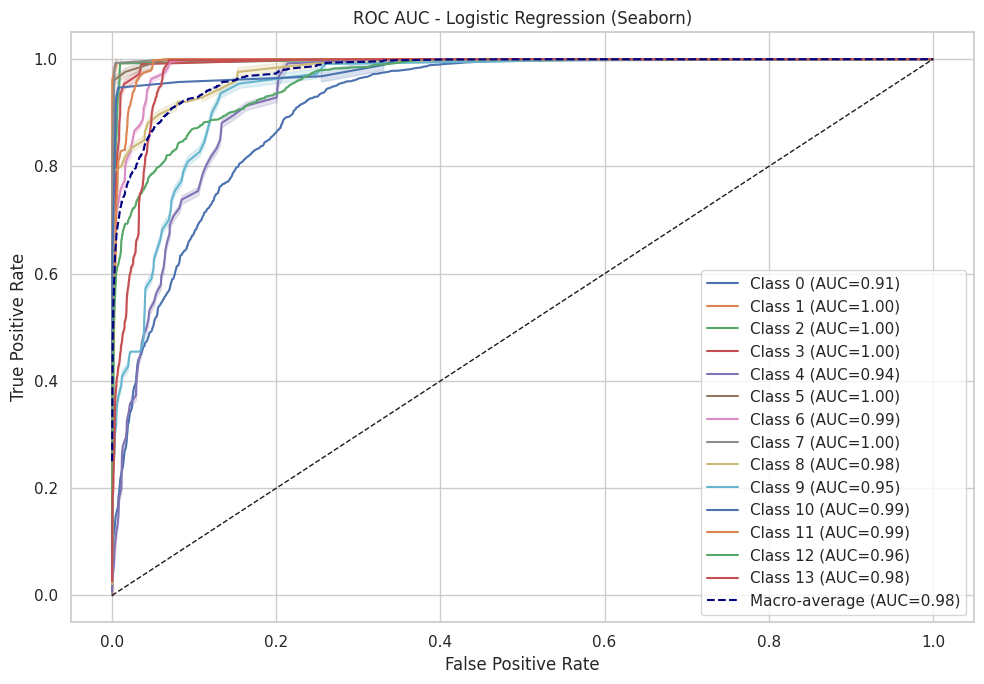

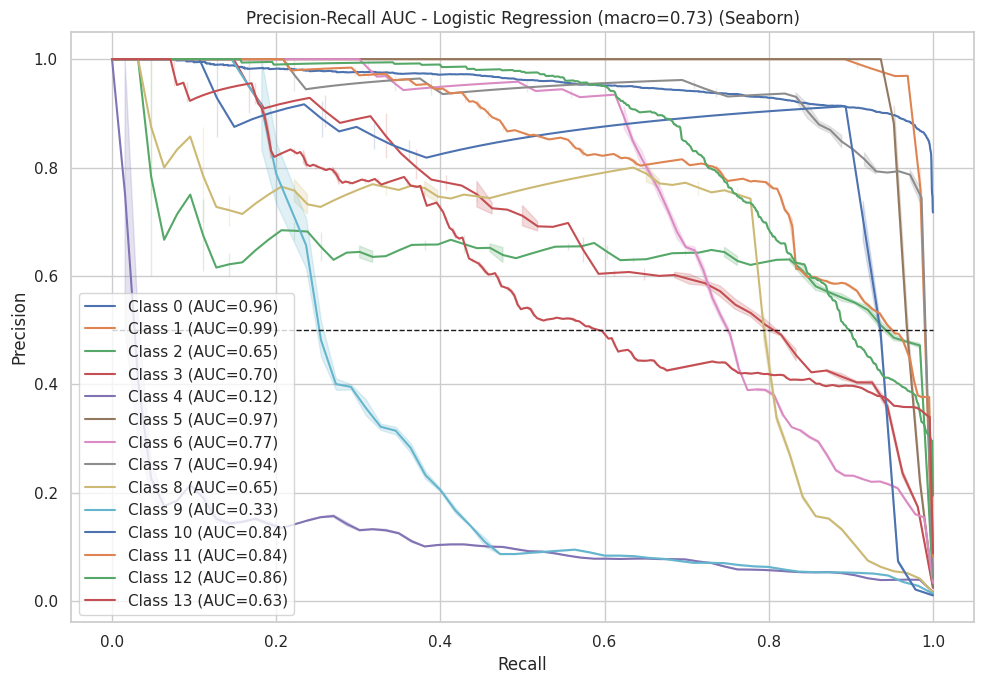

In [13]:
y_score = results["Logistic Regression"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "Logistic Regression")
plot_pr_auc_seaborn(y_test_bin, y_score, "Logistic Regression")

### SVM

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True)

param_grid = {'C': [1, 2, 3, 4, 5], 'kernel': ['linear', 'poly', 'rbf']}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["SVM"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [15]:
best_model

SVC(C=5, kernel='linear', probability=True)

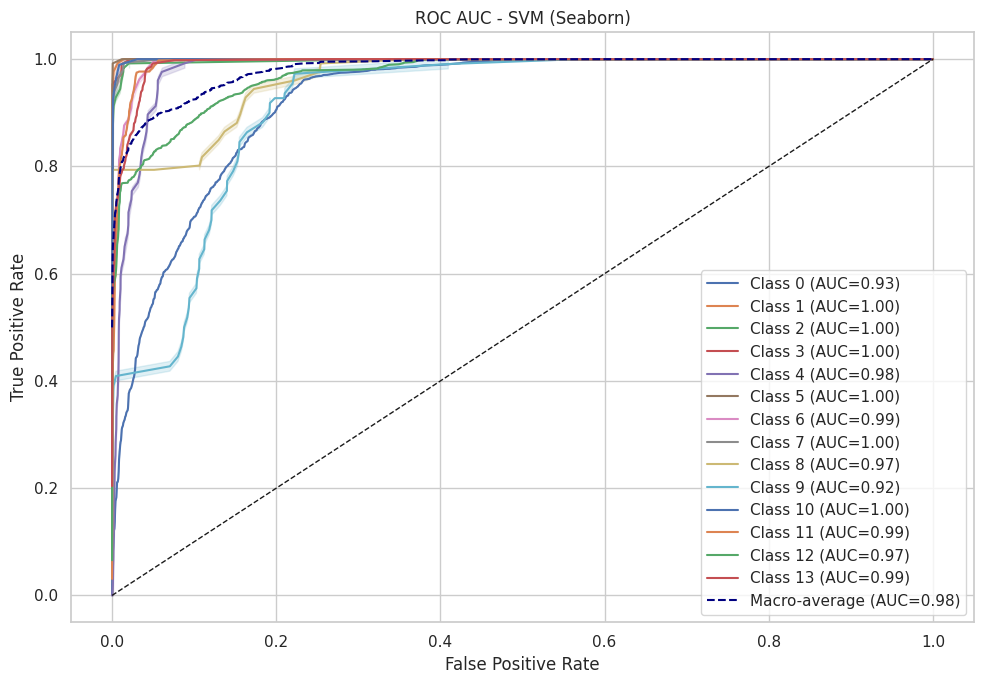

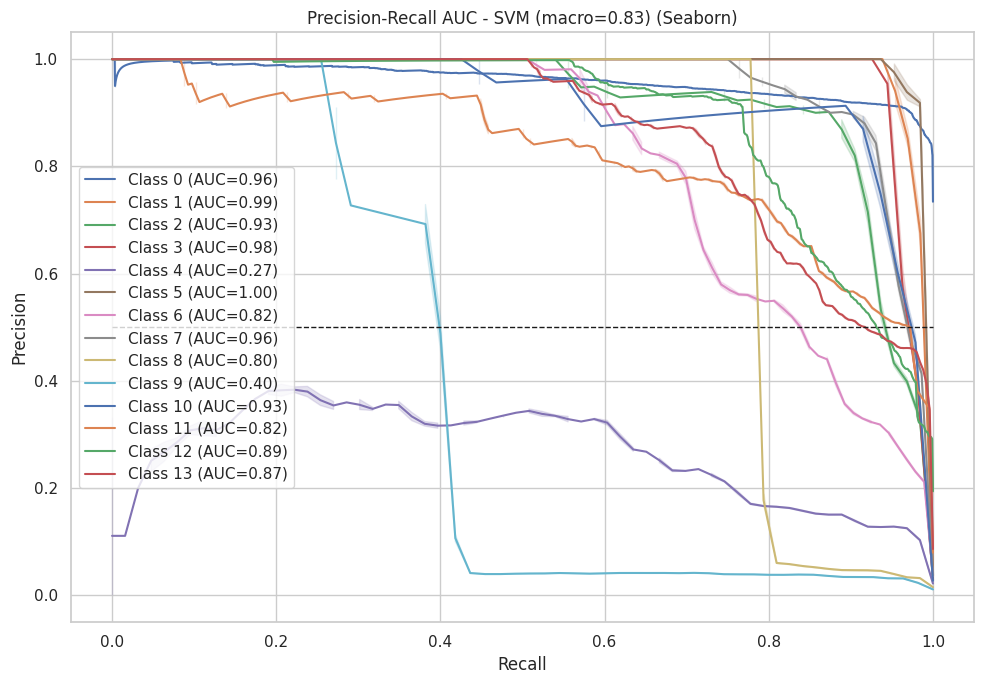

In [16]:
y_score = results["SVM"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "SVM")
plot_pr_auc_seaborn(y_test_bin, y_score, "SVM")

### Random Forest Classifier

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(random_state=SEED)

param_grid = {'n_estimators': [25, 50, 75, 100], 'criterion': ['gini', 'entropy', 'log_loss']}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["Random Forest"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [18]:
best_model

RandomForestClassifier(criterion='entropy', random_state=42)

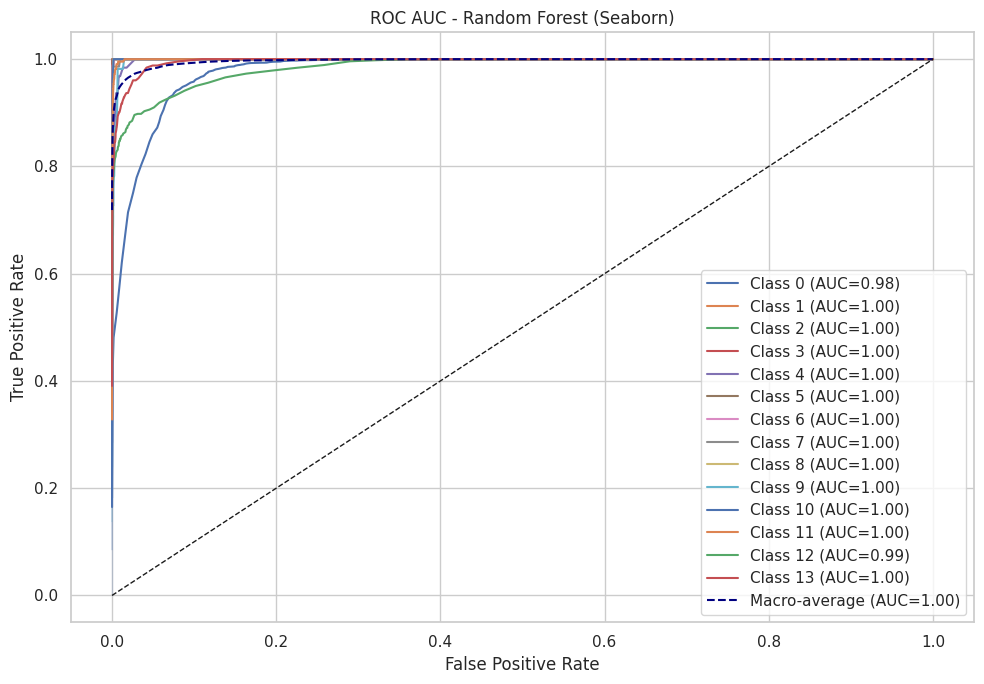

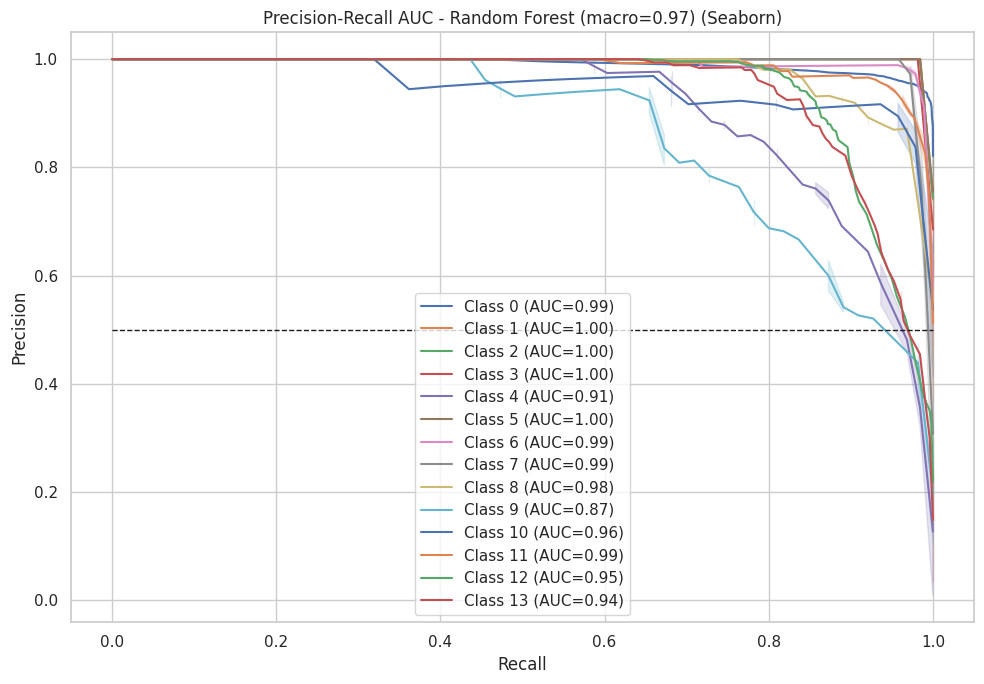

In [19]:
y_score = results["Random Forest"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "Random Forest")
plot_pr_auc_seaborn(y_test_bin, y_score, "Random Forest")

### XGBoost

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)

{'n_estimators': [100, 200, 300, 400, 500], 'learning_rate': [0.1, 0.2, 0.3]}
gs = GridSearchCV(
    model, param_grid, cv=3, scoring='roc_auc_ovr', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
y_score = best_model.predict_proba(X_test)
results["XGBoost"] = {
    'model': best_model,
    'y_score': y_score
}

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:39:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:39:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:39:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "criterion" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ltimindtree/Documents/personal/code/AIMLCZG628T/env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:39:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "criterion" } are

In [21]:
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, criterion='gini', device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=75, n_jobs=None, ...)

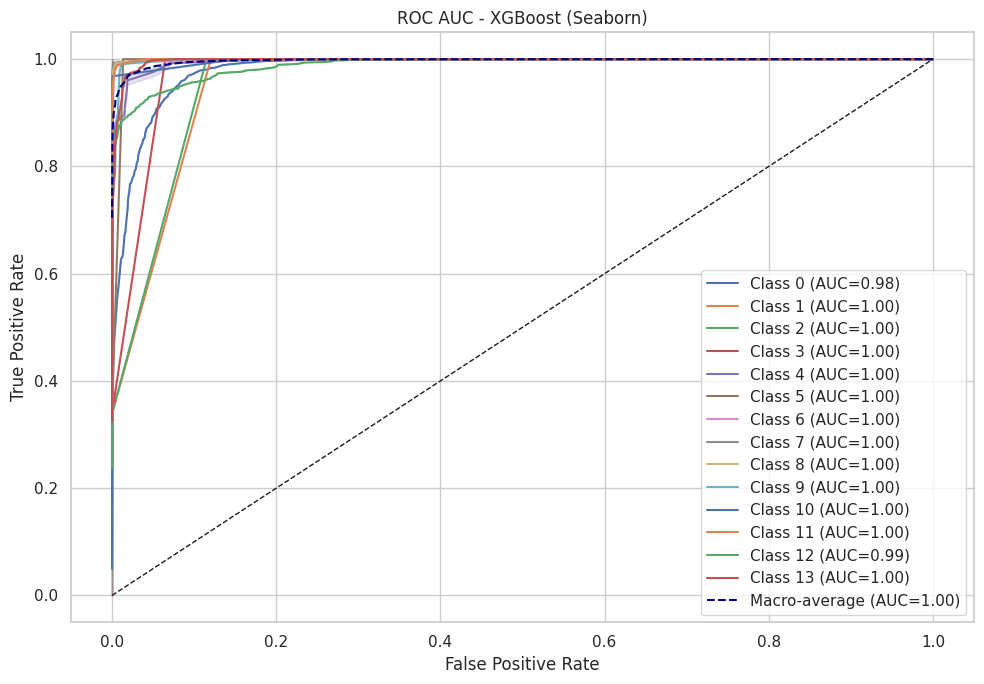

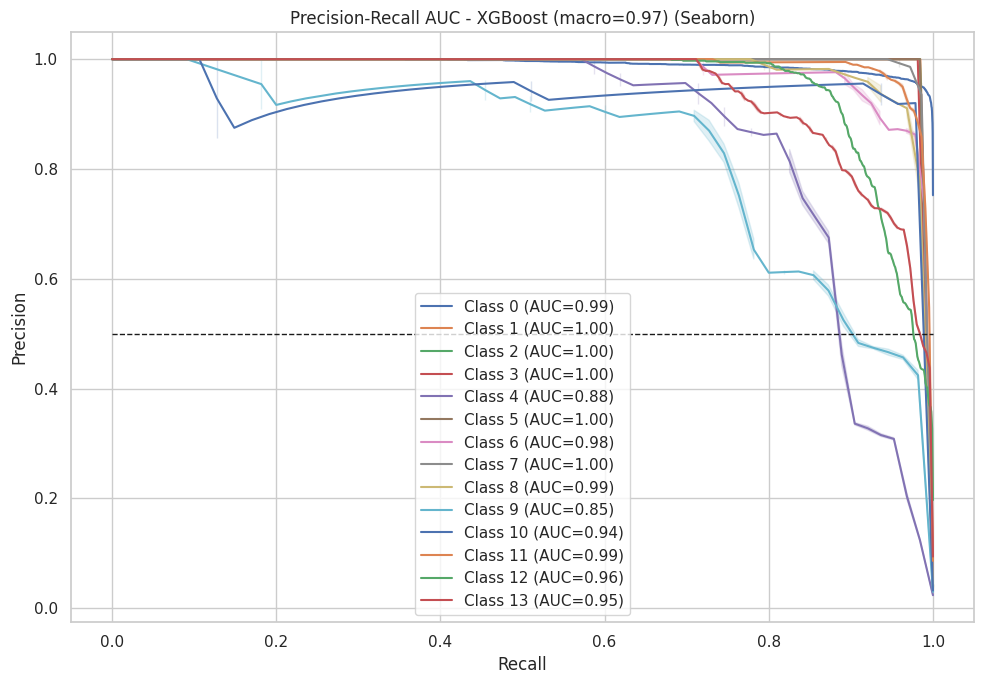

In [22]:
y_score = results["XGBoost"]['y_score']
plot_roc_auc_seaborn(y_test_bin, y_score, "XGBoost")
plot_pr_auc_seaborn(y_test_bin, y_score, "XGBoost")